In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical


In [32]:

# Load fresh data
(X_train, Y_train), (X_test, Y_test) = cifar10.load_data()

print("Before normalization:", X_train.min(), X_train.max())

# Normalize ONCE
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("After normalization:", X_train.min(), X_train.max())

Before normalization: 0 255
After normalization: 0.0 1.0


In [63]:
# One-hot encode labels
train_labels = to_categorical(Y_train, 10)
test_labels = to_categorical(Y_test, 10)


class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']


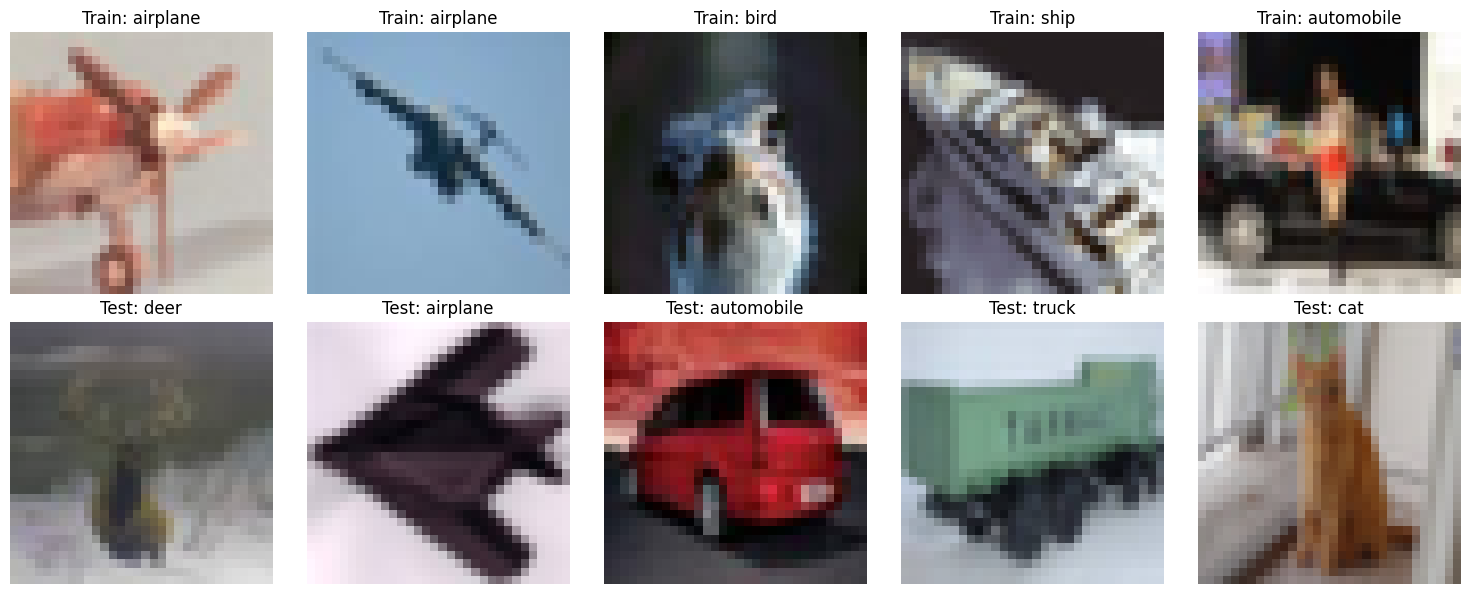

In [64]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Select 5 random training and 5 random testing images
train_indices = np.random.choice(X_train.shape[0], 5, replace=False)
test_indices = np.random.choice(X_test.shape[0], 5, replace=False)

plt.figure(figsize=(15, 6))

# task a) plot 5 random training and 5 random testing images with their labels
# Plot 5 random training images
for i in range(5):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[train_indices[i]])
    plt.title(f"Train: {class_names[(Y_train[train_indices[i]][0])]}")
    plt.axis('off')

# Plot 5 random testing images
for i in range(5):
    plt.subplot(2, 5, i + 6)
    plt.imshow(X_test[test_indices[i]])
    plt.title(f"Test: {class_names[(Y_test[test_indices[i]][0])]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Model 1 - L=2 with Max Pooling

In [69]:
# Model 1 — L=2 with Max Pooling
model_L2_max = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_L2_max.summary()


Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4661 - loss: 1.4850 - val_accuracy: 0.5671 - val_loss: 1.2284
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6105 - loss: 1.1066 - val_accuracy: 0.6290 - val_loss: 1.0537
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6668 - loss: 0.9614 - val_accuracy: 0.6567 - val_loss: 0.9866
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7004 - loss: 0.8588 - val_accuracy: 0.6849 - val_loss: 0.9238
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7316 - loss: 0.7723 - val_accuracy: 0.6916 - val_loss: 0.9002
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7566 - loss: 0.6981 - val_accuracy: 0.6877 - val_loss: 0.9221
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7797 - loss: 0.6282 - val_accuracy: 0.6854 - val_loss: 0.9302
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8045 - loss: 0.5609 - val_accuracy: 0.

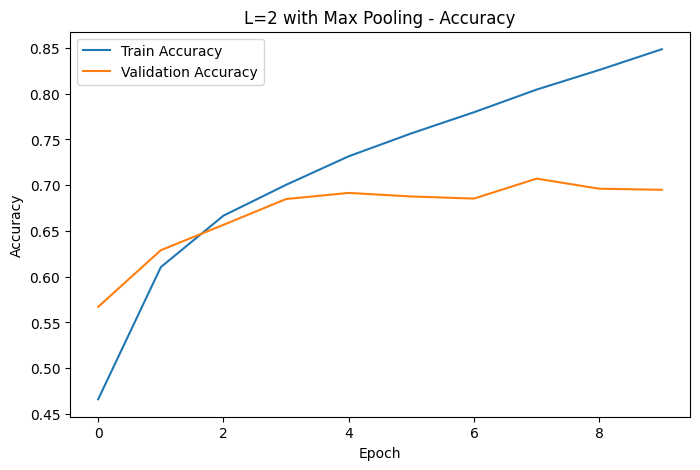

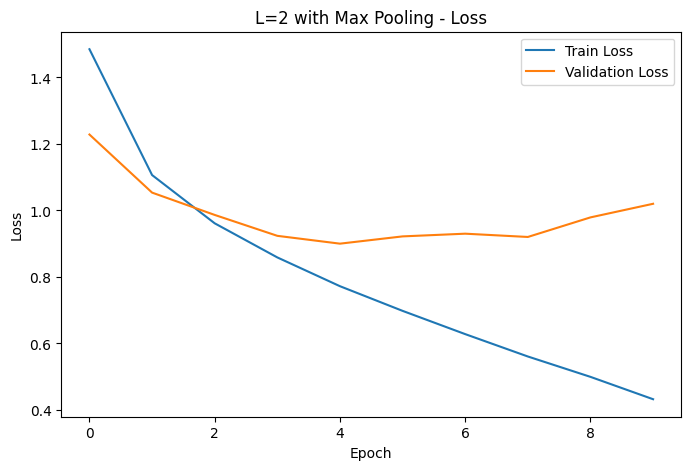

In [71]:
model_L2_max.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_L2_max = model_L2_max.fit(
    X_train,
    train_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

test_loss_L2_max, test_acc_L2_max = model_L2_max.evaluate(X_test, test_labels, verbose=0)
print("L=2 with Max Pooling")
print("Test Loss:", test_loss_L2_max)
print("Test Accuracy:", test_acc_L2_max)

plt.figure(figsize=(8, 5))
plt.plot(history_L2_max.history['accuracy'], label='Train Accuracy')
plt.plot(history_L2_max.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("L=2 with Max Pooling - Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_L2_max.history['loss'], label='Train Loss')
plt.plot(history_L2_max.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("L=2 with Max Pooling - Loss")
plt.legend()
plt.show()

## Model 2 - L=2 with Average Pooling

In [72]:
# Model 1 — L=2 with Average Pooling
model_L2_avg = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.AveragePooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.AveragePooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_L2_avg.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_10            │ (None, 16, 16, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_11            │ (None, 8, 8, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4360 - loss: 1.5701 - val_accuracy: 0.5194 - val_loss: 1.3735
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.5688 - loss: 1.2106 - val_accuracy: 0.5849 - val_loss: 1.1756
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6217 - loss: 1.0701 - val_accuracy: 0.6217 - val_loss: 1.0866
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6565 - loss: 0.9785 - val_accuracy: 0.6429 - val_loss: 1.0261
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.6808 - loss: 0.9076 - val_accuracy: 0.6519 - val_loss: 1.0029
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7010 - loss: 0.8500 - val_accuracy: 0.6749 - val_loss: 0.9451
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7249 - loss: 0.7890 - val_accuracy: 0.6791 - val_loss: 0.9294
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7391 - loss: 0.7431 - val_accu

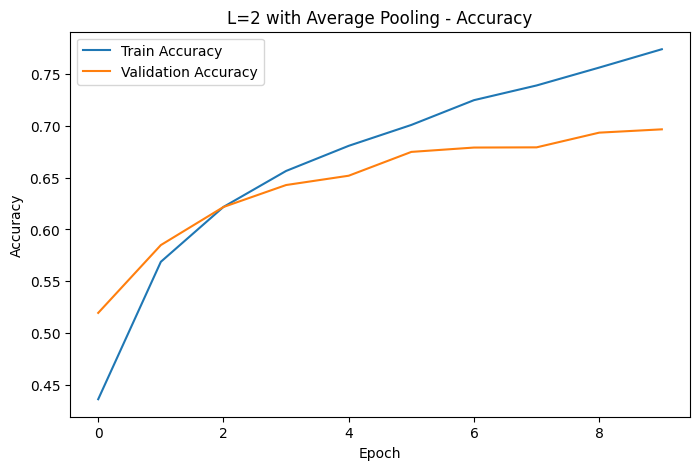

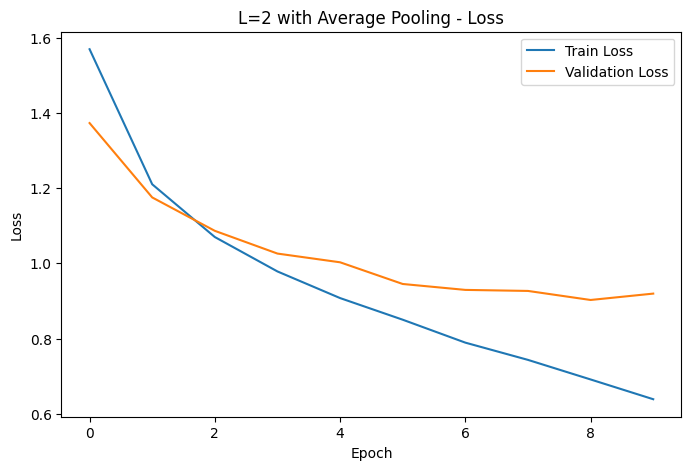

In [73]:
model_L2_avg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_L2_avg = model_L2_avg.fit(
    X_train,
    train_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

test_loss_L2_avg, test_acc_L2_avg = model_L2_avg.evaluate(X_test, test_labels, verbose=0)
print("L=2 with Average Pooling")
print("Test Loss:", test_loss_L2_avg)
print("Test Accuracy:", test_acc_L2_avg)

plt.figure(figsize=(8, 5))
plt.plot(history_L2_avg.history['accuracy'], label='Train Accuracy')
plt.plot(history_L2_avg.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("L=2 with Average Pooling - Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_L2_avg.history['loss'], label='Train Loss')
plt.plot(history_L2_avg.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("L=2 with Average Pooling - Loss")
plt.legend()
plt.show()

## Model 3 - L=3 with Max Pooling

In [74]:
## Model 2 — L=3 with Max Pooling

model_L3_max = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_L3_max.summary()

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_38 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.4509 - loss: 1.5022 - val_accuracy: 0.5827 - val_loss: 1.1795
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.6168 - loss: 1.0803 - val_accuracy: 0.6522 - val_loss: 0.9973
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.6844 - loss: 0.8984 - val_accuracy: 0.6900 - val_loss: 0.8954
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7251 - loss: 0.7858 - val_accuracy: 0.6871 - val_loss: 0.9205
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7624 - loss: 0.6884 - val_accuracy: 0.7302 - val_loss: 0.8003
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7868 - loss: 0.6080 - val_accuracy: 0.7335 - val_loss: 0.7948
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8144 - loss: 0.5307 - val_accuracy: 0.7368 - val_loss: 0.7945
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8388 - loss: 0.4621 - val_accu

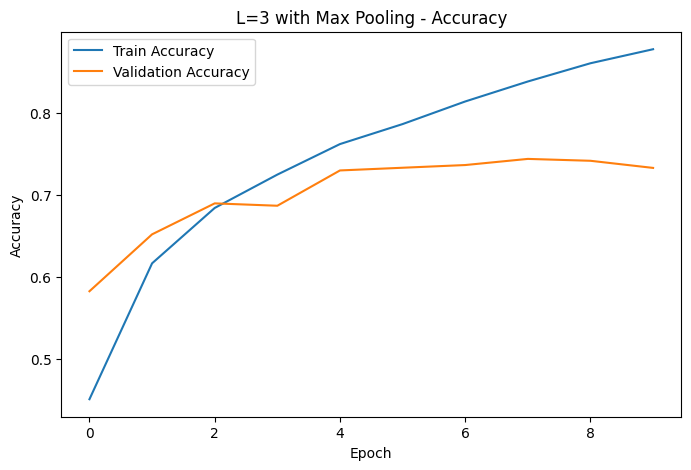

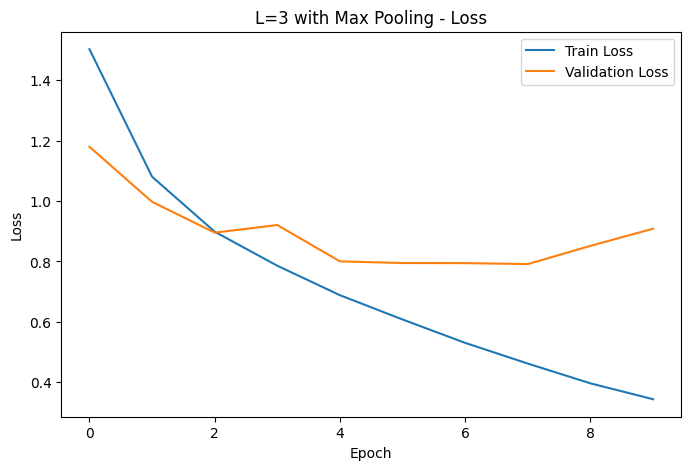

In [75]:
model_L3_max.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_L3_max = model_L3_max.fit(
    X_train,
    train_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

test_loss_L3_max, test_acc_L3_max = model_L3_max.evaluate(X_test, test_labels, verbose=0)
print("L=3 with Max Pooling")
print("Test Loss:", test_loss_L3_max)
print("Test Accuracy:", test_acc_L3_max)

plt.figure(figsize=(8, 5))
plt.plot(history_L3_max.history['accuracy'], label='Train Accuracy')
plt.plot(history_L3_max.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("L=3 with Max Pooling - Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_L3_max.history['loss'], label='Train Loss')
plt.plot(history_L3_max.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("L=3 with Max Pooling - Loss")
plt.legend()
plt.show()

## Model 4 - L=3 with Average Pooling

In [76]:
model_L3_avg = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.AveragePooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.AveragePooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.AveragePooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_L3_avg.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_41 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_12            │ (None, 16, 16, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_13            │ (None, 8, 8, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_14            │ (None, 4, 4, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_18 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,810 (1.36 MB)

 Trainable params: 356,810 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.4085 - loss: 1.6239 - val_accuracy: 0.5038 - val_loss: 1.3675
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5551 - loss: 1.2540 - val_accuracy: 0.5970 - val_loss: 1.1501
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6141 - loss: 1.0869 - val_accuracy: 0.6223 - val_loss: 1.0746
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6574 - loss: 0.9700 - val_accuracy: 0.6351 - val_loss: 1.0435
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6873 - loss: 0.8849 - val_accuracy: 0.6864 - val_loss: 0.8983
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 12ms/step - accuracy: 0.7128 - loss: 0.8144 - val_accuracy: 0.6857 - val_loss: 0.9028
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7352 - loss: 0.7562 - val_accuracy: 0.6959 - val_loss: 0.8928
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.7571 - loss: 0.6947 - val_accu

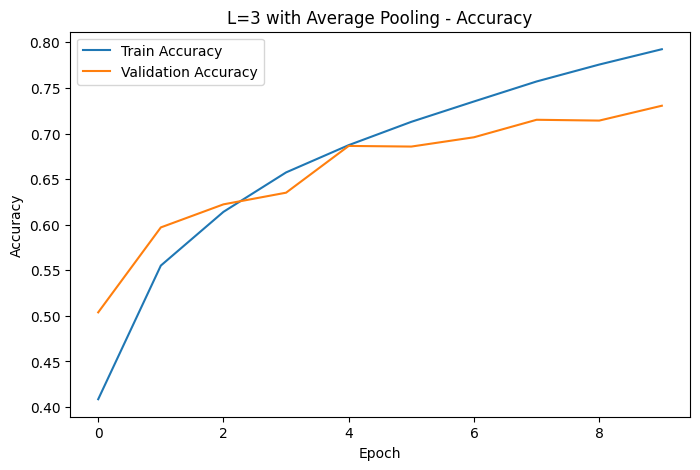

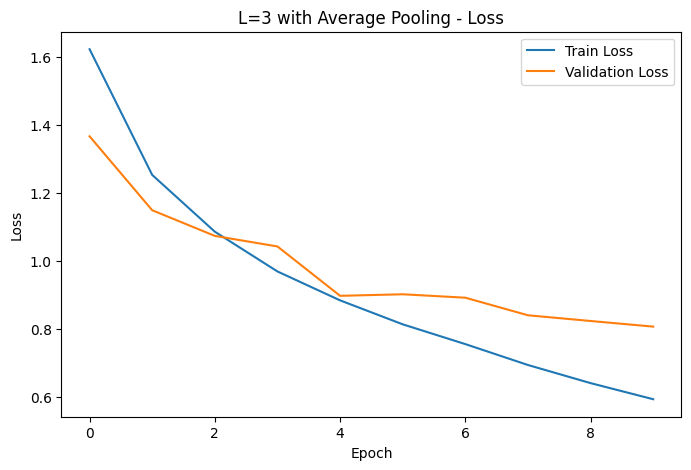

In [77]:
model_L3_avg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_L3_avg = model_L3_avg.fit(
    X_train,
    train_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

test_loss_L3_avg, test_acc_L3_avg = model_L3_avg.evaluate(X_test, test_labels, verbose=0)
print("L=3 with Average Pooling")
print("Test Loss:", test_loss_L3_avg)
print("Test Accuracy:", test_acc_L3_avg)

plt.figure(figsize=(8, 5))
plt.plot(history_L3_avg.history['accuracy'], label='Train Accuracy')
plt.plot(history_L3_avg.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("L=3 with Average Pooling - Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_L3_avg.history['loss'], label='Train Loss')
plt.plot(history_L3_avg.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("L=3 with Average Pooling - Loss")
plt.legend()
plt.show()

## Model 5 - L=4 with Max Pooling

In [79]:
model_L4_max = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_L4_max.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 520,906 (1.99 MB)

 Trainable params: 520,906 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.4293 - loss: 1.5563 - val_accuracy: 0.5301 - val_loss: 1.3108
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6080 - loss: 1.1004 - val_accuracy: 0.6458 - val_loss: 1.0025
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.6864 - loss: 0.8931 - val_accuracy: 0.6873 - val_loss: 0.8898
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7409 - loss: 0.7365 - val_accuracy: 0.7063 - val_loss: 0.8674
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7790 - loss: 0.6255 - val_accuracy: 0.7055 - val_loss: 0.8547
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8158 - loss: 0.5294 - val_accuracy: 0.7440 - val_loss: 0.7526
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8481 - loss: 0.4331 - val_accuracy: 0.7420 - val_loss: 0.7795
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.8792 - loss: 0.3453 - val_acc

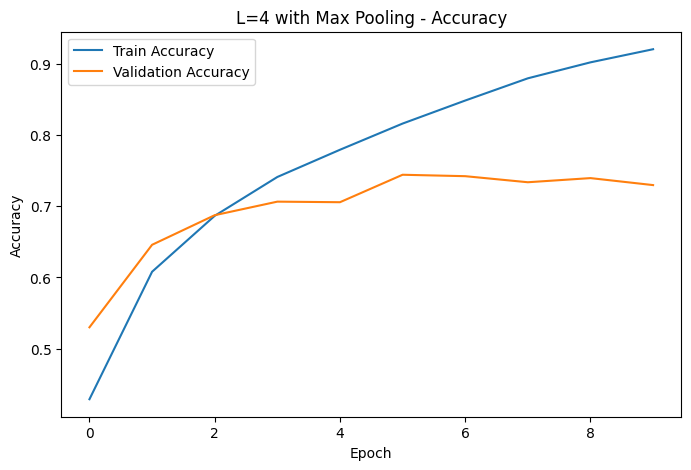

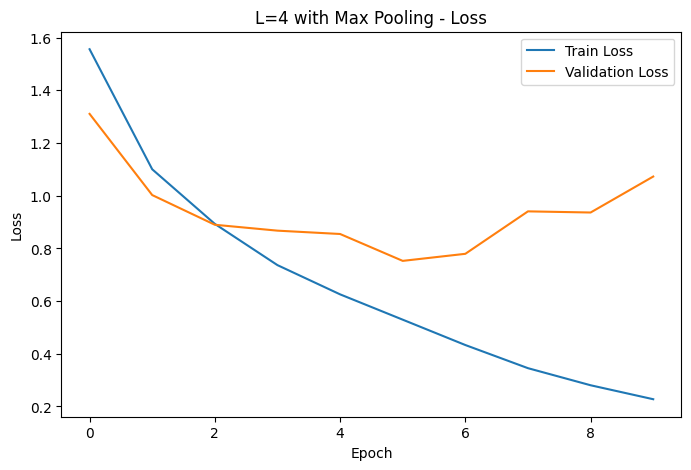

In [80]:
model_L4_max.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_L4_max = model_L4_max.fit(
    X_train,
    train_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

test_loss_L4_max, test_acc_L4_max = model_L4_max.evaluate(X_test, test_labels, verbose=0)
print("L=4 with Max Pooling")
print("Test Loss:", test_loss_L4_max)
print("Test Accuracy:", test_acc_L4_max)

plt.figure(figsize=(8, 5))
plt.plot(history_L4_max.history['accuracy'], label='Train Accuracy')
plt.plot(history_L4_max.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("L=4 with Max Pooling - Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_L4_max.history['loss'], label='Train Loss')
plt.plot(history_L4_max.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("L=4 with Max Pooling - Loss")
plt.legend()
plt.show()

## Model 6 - L=4 with Average Pooling

In [81]:
model_L4_avg = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.AveragePooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.AveragePooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.AveragePooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.AveragePooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_L4_avg.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_52 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_15            │ (None, 16, 16, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_16            │ (None, 8, 8, 64)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_17            │ (None, 4, 4, 128)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_18            │ (None, 2, 2, 256)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_21 (Flatten)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 520,906 (1.99 MB)

 Trainable params: 520,906 (1.99 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3851 - loss: 1.6481 - val_accuracy: 0.4519 - val_loss: 1.4855
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.5176 - loss: 1.3271 - val_accuracy: 0.5108 - val_loss: 1.3527
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.5875 - loss: 1.1486 - val_accuracy: 0.6233 - val_loss: 1.0653
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.6378 - loss: 1.0229 - val_accuracy: 0.6494 - val_loss: 0.9840
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.6726 - loss: 0.9290 - val_accuracy: 0.6708 - val_loss: 0.9398
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7062 - loss: 0.8376 - val_accuracy: 0.6862 - val_loss: 0.8858
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7276 - loss: 0.7724 - val_accuracy: 0.7121 - val_loss: 0.8241
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.7526 - loss: 0.7044 - val_ac

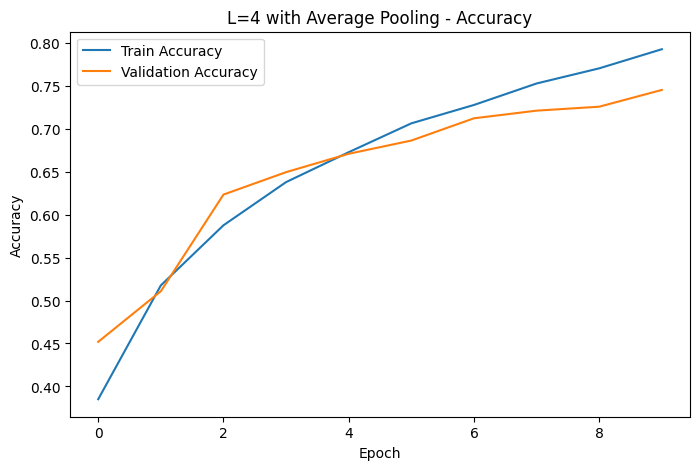

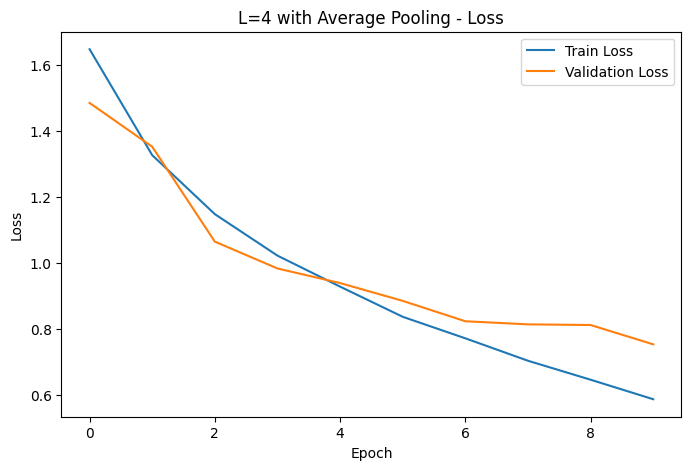

In [82]:
model_L4_avg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_L4_avg = model_L4_avg.fit(
    X_train,
    train_labels,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

test_loss_L4_avg, test_acc_L4_avg = model_L4_avg.evaluate(X_test, test_labels, verbose=0)
print("L=4 with Average Pooling")
print("Test Loss:", test_loss_L4_avg)
print("Test Accuracy:", test_acc_L4_avg)

plt.figure(figsize=(8, 5))
plt.plot(history_L4_avg.history['accuracy'], label='Train Accuracy')
plt.plot(history_L4_avg.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("L=4 with Average Pooling - Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_L4_avg.history['loss'], label='Train Loss')
plt.plot(history_L4_avg.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("L=4 with Average Pooling - Loss")
plt.legend()
plt.show()

## Final Comparison

In [83]:
print("Final Results: ")
print("L=2 with Max Pooling - Test Accuracy:", test_acc_L2_max)
print("L=2 with Average Pooling - Test Accuracy:", test_acc_L2_avg)
print("L=3 with Max Pooling - Test Accuracy:", test_acc_L3_max)
print("L=3 with Average Pooling - Test Accuracy:", test_acc_L3_avg)
print("L=4 with Max Pooling - Test Accuracy:", test_acc_L4_max)
print("L=4 with Average Pooling - Test Accuracy:", test_acc_L4_avg)

Final Results: 
L=2 with Max Pooling - Test Accuracy: 0.6898999810218811
L=2 with Average Pooling - Test Accuracy: 0.6898000240325928
L=3 with Max Pooling - Test Accuracy: 0.732699990272522
L=3 with Average Pooling - Test Accuracy: 0.722599983215332
L=4 with Max Pooling - Test Accuracy: 0.715399980545044
L=4 with Average Pooling - Test Accuracy: 0.7404000163078308
